<a href="https://colab.research.google.com/github/VrgiPramudya/computer-vision/blob/main/Jobsheet_02_Galih_Virgi_Pramudya_Visi_Komputer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum D1 – Memulai Klasifikasi Gambar dengan Dataset Sederhana

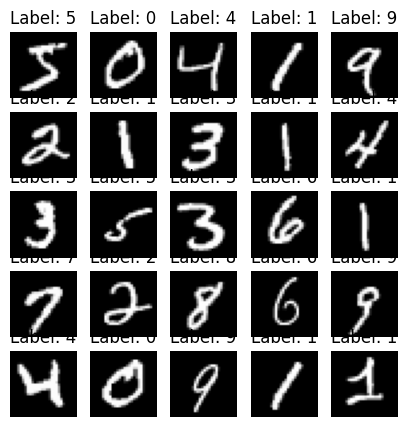

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Tampilkan contoh
plt.figure(figsize=(5,5))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.show()

#Praktikum D2 – Klasifikasi Gambar dengan Model Machine Learning Tradisional

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score

# Flatten
x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0

# SVM
clf = svm.SVC(kernel='rbf', gamma='scale')
clf.fit(x_train_flat[:5000], y_train[:5000]) # gunakan subset karena SVM berat
y_pred = clf.predict(x_test_flat)

print("Akurasi:", accuracy_score(y_test, y_pred))

Akurasi: 0.9513


#Praktikum D3 – CNN Sederhana (MNIST)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.9535 - loss: 0.1535 - val_accuracy: 0.9860 - val_loss: 0.0520
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 51s 30ms/step - accuracy: 0.9848 - loss: 0.0501 - val_accuracy: 0.9852 - val_loss: 0.0517
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 47s 28ms/step - accuracy: 0.9880 - loss: 0.0366 - val_accuracy: 0.9875 - val_loss: 0.0424
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 26ms/step - accuracy: 0.9916 - loss: 0.0261 - val_accuracy: 0.9898 - val_loss: 0.0383
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9931 - loss: 0.0206 - val_accuracy: 0.9917 - val_loss: 0.0331


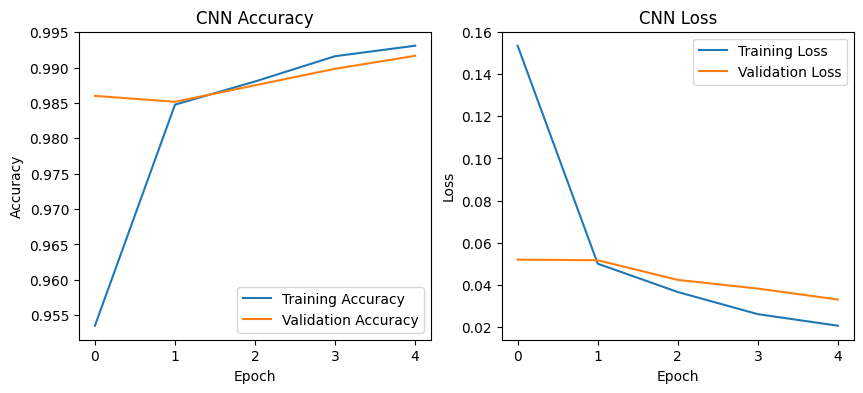

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# Load MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_cnn = x_train.reshape(-1,28,28,1) / 255.0
x_test_cnn = x_test.reshape(-1,28,28,1) / 255.0
model = models.Sequential([
  layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),

  # -- TUGAS KECIL: Tambahan Lapisan Conv2D dan MaxPooling2D --
  layers.Conv2D(64, (3,3), activation='relu'),
  layers.MaxPooling2D((2,2)),

  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])
history = model.fit(x_train_cnn, y_train, epochs=5, validation_split=0.1)

# ===== Plot history =====
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Praktikum D4 – CNN dengan Dataset CIFAR-10 (RGB)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1247s 7us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.3561 - loss: 1.7479 - val_accuracy: 0.5160 - val_loss: 1.3617
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.4744 - loss: 1.4514 - val_accuracy: 0.5890 - val_loss: 1.1834
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.5214 - loss: 1.3302 - val_accuracy: 0.6064 - val_loss: 1.1511
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 37ms/step - accuracy: 0.5525 - loss: 1.2440 - val_accuracy: 0.6422 - val_loss: 1.0389
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.5755 - loss: 1.1840 - val_accuracy: 0.6516 - val_loss: 1.0045
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.5924 - loss: 1.1369 - val_accuracy: 0.6772 - val_loss: 0.9477
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.6127 - loss: 1.0895 - val_accuracy: 0.6774 - val_loss: 0.9257
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 37ms/step - accuracy: 0.6205 -

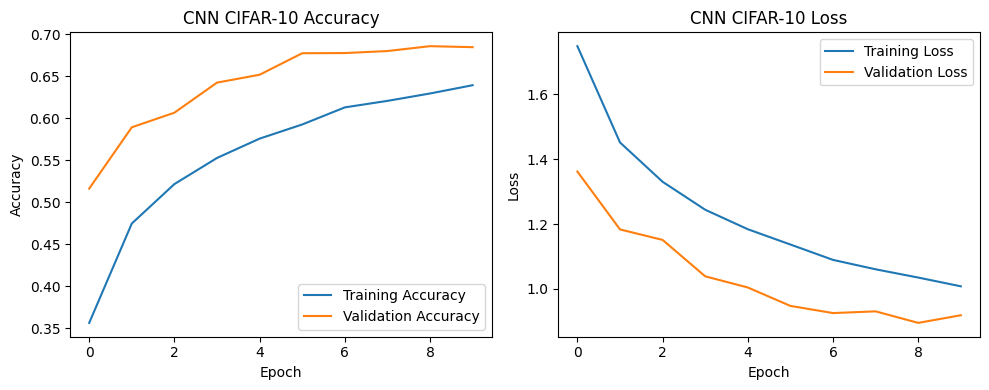

In [ ]:
# 1. Import library yang dibutuhkan
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

# 2. Load dan normalisasi dataset
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c / 255.0, x_test_c / 255.0

# 3. Membuat arsitektur model
model_cifar = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # TUGAS KECIL: Tambahan Dropout
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# 4. Compile model
model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# 5. Training model
# Proses ini akan jauh lebih cepat jika GPU sudah aktif
history_cifar = model_cifar.fit(x_train_c, y_train_c, epochs=10, validation_split=0.1)

# 6. Plot history (Akurasi dan Loss)
plt.figure(figsize=(10,4))

# Plot Akurasi
plt.subplot(1,2,1)
plt.plot(history_cifar.history['accuracy'], label='Training Accuracy')
plt.plot(history_cifar.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN CIFAR-10 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history_cifar.history['loss'], label='Training Loss')
plt.plot(history_cifar.history['val_loss'], label='Validation Loss')
plt.title('CNN CIFAR-10 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

#Praktikum D5 – Transfer Learning (VGG16/ResNet50)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2373s 2s/step - accuracy: 0.5692 - loss: 1.2348 - val_accuracy: 0.6672 - val_loss: 0.9492
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2391s 2s/step - accuracy: 0.6946 - loss: 0.8813 - val_accuracy: 0.7080 - val_loss: 0.8363
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2416s 2s/step - accuracy: 0.7305 - loss: 0.7764 - val_accuracy: 0.7310 - val_loss: 0.7834
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2443s 2s/step - accuracy: 0.7564 - loss: 0.7052 - val_accuracy: 0.7346 - val_loss: 0.7585
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 2363s 2s/step - accuracy: 0.7765 - loss: 0.6462 - val_accuracy: 0.7388 - val_loss: 0.7555


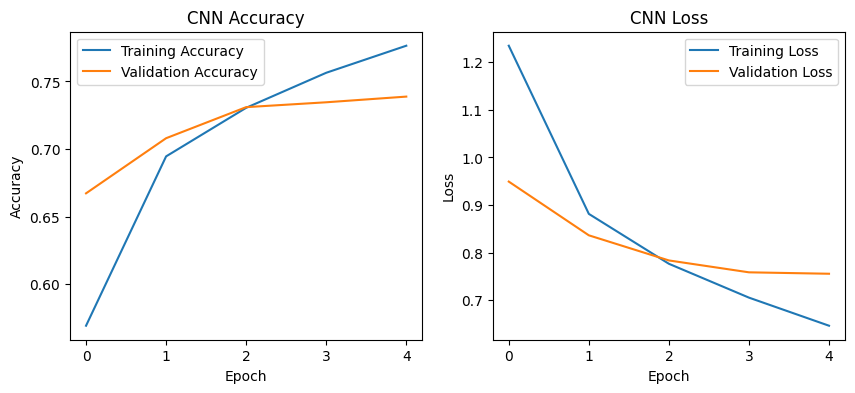

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

# Load dan normalisasi dataset
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
x_train_c, x_test_c = x_train_c / 255.0, x_test_c / 255.0

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32,32,3))

# -- TUGAS KECIL: FINE TUNING (Aktifkan beberapa layer terakhir) --
base_model.trainable = True
# Bekukan semua layer kecuali 4 layer konvolusi terakhir
for layer in base_model.layers[:-4]:
    layer.trainable = False
# -----------------------------------------------------------------

model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Gunakan learning rate (lr) yang sangat kecil untuk Fine-Tuning agar bobot tidak rusak
model_tl.compile(optimizer=Adam(learning_rate=1e-5),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_tl = model_tl.fit(x_train_c, y_train_c, epochs=5, validation_split=0.1)

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Praktikum D6 – Evaluasi dengan Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 150s 479ms/step
              precision    recall  f1-score   support

           0       0.84      0.75      0.79      1000
           1       0.86      0.80      0.83      1000
           2       0.58      0.75      0.65      1000
           3       0.64      0.47      0.54      1000
           4       0.74      0.60      0.66      1000
           5       0.59      0.69      0.64      1000
           6       0.74      0.78      0.76      1000
           7       0.80      0.77      0.79      1000
           8       0.83      0.85      0.84      1000
           9       0.75      0.84      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



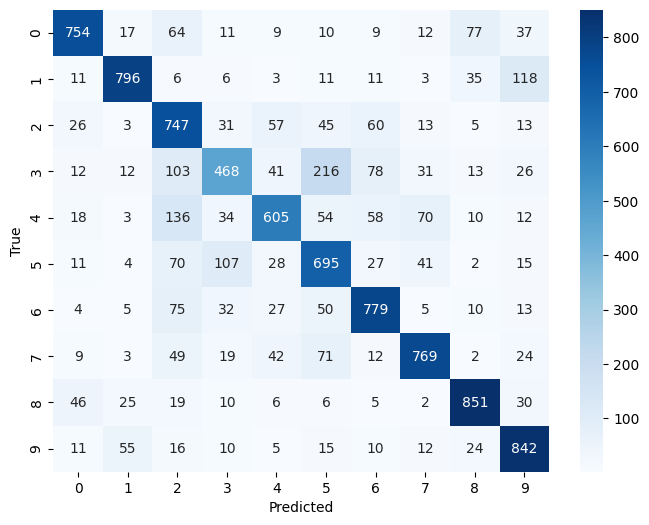

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model_tl.predict(x_test_c).argmax(axis=1)

print(classification_report(y_test_c, y_pred))

cm = confusion_matrix(y_test_c, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#Latihan Soal

Silahkan upload gambar angka tulisan tangan Anda (jpg/png):


Saving WhatsApp Image 2026-09-24 at 08.26.49.jpeg to WhatsApp Image 2026-09-24 at 08.26.49 (1).jpeg


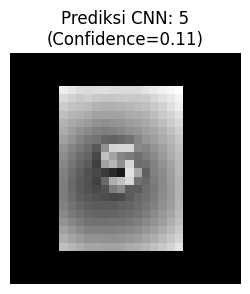

Rekap Prediksi (CNN):
- WhatsApp Image 2026-09-24 at 08.26.49 (1).jpeg -> Ditebak sebagai angka: 5 (probabilitas=0.111)


In [3]:
from google.colab import files
import numpy as np
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# ===== 1) Upload file foto tulisan angka =====
print("Silahkan upload gambar angka tulisan tangan Anda (jpg/png):")
uploaded = files.upload()

# ===== 2) Utilitas Preprocess =====
def preprocess_to_mnist_28x28(img_pil):
    # Grayscale + autocontrast
    img = img_pil.convert('L')
    img = ImageOps.autocontrast(img)
    arr = np.array(img).astype(np.uint8)

    # Jika rata-rata terang (kertas putih), invert supaya digit menjadi putih di atas latar gelap
    if arr.mean() > 127:
        img = ImageOps.invert(img)
        arr = np.array(img)

    # Binarisasi ringan untuk cari bbox digit
    thr = np.mean(arr) * 0.8
    mask = arr > thr
    if mask.any():
        ys, xs = np.where(mask)
        y0, y1 = ys.min(), ys.max()
        x0, x1 = xs.min(), xs.max()
        img = img.crop((x0, y0, x1+1, y1+1))

    # Resize ke 20x20 dengan aspect ratio
    img.thumbnail((20, 20), Image.Resampling.LANCZOS)
    w, h = img.size

    # Pad ke 28x28 dan center
    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(img, ((28 - w)//2, (28 - h)//2))

    # Normalisasi ke [0,1]
    arr = np.array(canvas).astype('float32') / 255.0
    arr = arr[..., None]
    return canvas, arr

# --- FIX: Model definition moved here to resolve NameError ---
# Define the CNN model (copied from Praktikum 3 / cell h1em2qEwR0F6)
model = models.Sequential([
  layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
  layers.MaxPooling2D((2,2)),
  layers.Conv2D(64, (3,3), activation='relu'),
  layers.MaxPooling2D((2,2)),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(10, activation='softmax')
])

# Compile the model (optimizer and loss can be minimal for just prediction, if not trained here)
# Assuming it's already trained, compilation isn't strictly necessary for just 'predict'
# but it's good practice if this cell were to train it.
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# ---------------------------------------------------------------------------------

# ===== 3) Prediksi dengan Model CNN (Pilihan A) =====
results = []
for fname in uploaded.keys():
    img_pil = Image.open(fname)
    disp, x = preprocess_to_mnist_28x28(img_pil)

    x_batch = np.expand_dims(x, axis=0)
    probs = model.predict(x_batch, verbose=0)[0] # Menggunakan model_cnn dari D3
    pred = int(np.argmax(probs))
    conf = float(np.max(probs))

    results.append((fname, pred, conf))

    # Tampilkan hasil
    plt.figure(figsize=(3,3))
    plt.imshow(disp, cmap='gray')
    plt.title(f"Prediksi CNN: {pred}\n(Confidence={conf:.2f})")
    plt.axis('off')
    plt.show()

# Rekap ringkas
print("Rekap Prediksi (CNN):")
for r in results:
    print(f"- {r[0]} -> Ditebak sebagai angka: {r[1]} (probabilitas={r[2]:.3f})")